# I - generar una poblacion sintetica

In [2]:
import pandas as pd
import numpy as np

In [3]:
np.random.seed(42)

In [4]:
population = pd.DataFrame({
    "customer_id": range(1, 100001),
    "age": np.random.randint(18, 71, 100000),
    "monthly_spending": np.random.normal(15, 3, 100000)
})

In [5]:
population.head()

,customer_id,age,monthly_spending
0,1,56,15.509233
1,2,69,11.393659
2,3,46,16.316485
3,4,32,11.737020
4,5,60,19.107418


# II - Calcular Promedio (μ)

In [6]:
population["monthly_spending"].mean()

np.float64(15.000240399223976)

# III - Tomar una muestra aleatoria

In [7]:
sample_100 = population.sample(100)
sample_500 = population.sample(500)
sample_1000 = population.sample(1000)
sample_10000 = population.sample(10000)


# IV - Crear una tabla comparativa

In [8]:
results = pd.DataFrame({
    "Sample Size":[100,500,1000,10000],
    "Mean":[
        sample_100["monthly_spending"].mean(),
        sample_500["monthly_spending"].mean(),
        sample_1000["monthly_spending"].mean(),
        sample_10000["monthly_spending"].mean()
    ]
})

results

,Sample Size,Mean
0,100,15.640719
1,500,14.816985
2,1000,14.912865
3,10000,15.050790


#### Los promedios de esta muestra son aproximados a la poblacion

# V - Visualizacion

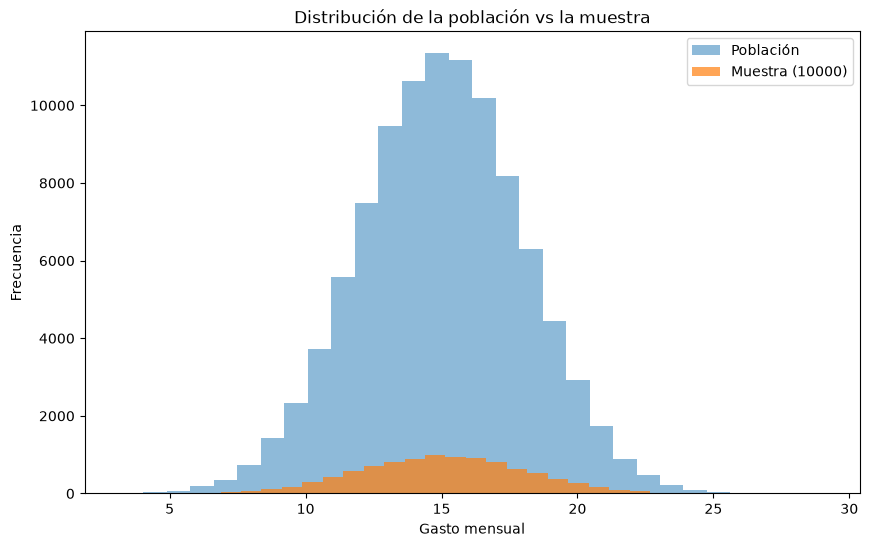

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(population["monthly_spending"],
         bins=30,
         alpha=0.5,
         label="Población")

plt.hist(sample_10000["monthly_spending"],
         bins=30,
         alpha=0.7,
         label="Muestra (10000)")

plt.xlabel("Gasto mensual")
plt.ylabel("Frecuencia")
plt.title("Distribución de la población vs la muestra")
plt.legend()

plt.show()

## 📌 Análisis de la visualización

En la gráfica se comparan las distribuciones del gasto mensual de la población y de una muestra aleatoria de 10,000 clientes.

A simple vista se observa que la población presenta barras con una frecuencia mucho mayor que la muestra. Esto es completamente esperado, ya que la población contiene un número significativamente superior de observaciones.

Sin embargo, lo importante no es la altura de las barras, sino la **forma de la distribución**. La muestra mantiene una distribución muy similar a la de la población, concentrando la mayor parte de los valores alrededor del mismo gasto mensual.

Esto demuestra que una muestra aleatoria suficientemente grande puede representar adecuadamente a la población, permitiendo obtener conclusiones confiables sin necesidad de analizar la totalidad de los datos.

En Ingeniería de Datos este principio es especialmente útil cuando se trabaja con millones de registros. En lugar de procesar un conjunto completo de datos para realizar análisis exploratorios, es posible utilizar una muestra representativa, reduciendo el tiempo de procesamiento y el consumo de recursos computacionales sin perder una visión general del comportamiento de los datos.

In [10]:
print(f"Media poblacional: {population['monthly_spending'].mean():.2f}")
print(f"Media muestral: {sample_10000['monthly_spending'].mean():.2f}")

print(f"Desviación estándar poblacional: {population['monthly_spending'].std():.2f}")
print(f"Desviación estándar muestral: {sample_10000['monthly_spending'].std():.2f}")

Media poblacional: 15.00
Media muestral: 15.05
Desviación estándar poblacional: 3.01
Desviación estándar muestral: 3.04
